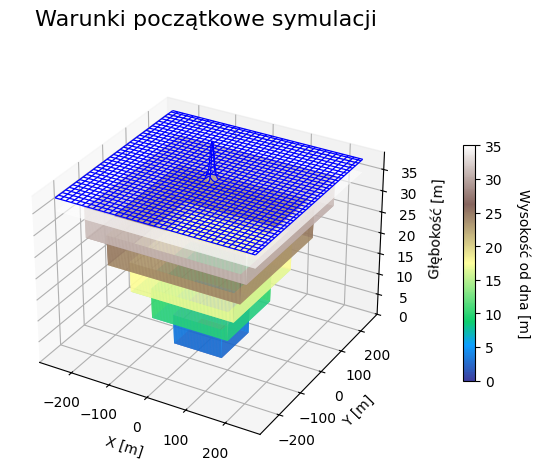

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# ==================== PARAMETRY ====================
L = 500    # długość [m]
W = 500   # szerokość [m]
H_max = 38 # maksymalna głębokość [m]


terrace_depths = [ 7, 14, 21, 28, 35]  # ostatnia wartość najwyżej od dna

# ==================== SIATKA ====================
x = np.linspace(-L/2, L/2, 250)
y = np.linspace(-W/2, W/2, 250)
X, Y = np.meshgrid(x, y)


Z = np.zeros_like(X)

# ==================== TYLKO PIONOWE ŚCIANY I TARASY ====================
for i, depth in enumerate(terrace_depths):

    #ostatni taras ma 30 Metrów, pierwszy ma 
    fraction = (depth / H_max)
    Tarrace_from_shore_x =30+(L/2 -60) * (1 - fraction)  #granica wyższego poziomu w x 
    Tarrace_from_shore_y =30+(W/2 -60) * (1 - fraction)  #granica wyższego poziomu w y 

    # Obszar, w którym już jest płycej niż bieżący taras
    inner_mask = (np.abs(X) < L/2 - Tarrace_from_shore_x) & (np.abs(Y) < W/2 - Tarrace_from_shore_y)

    # Wszystko poza tym obszarem dostaje bieżącą głębokość
    Z = np.where(inner_mask, Z, depth)


# ==================== WIZUALIZACJA ====================
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

surf = ax.plot_surface(X, Y, Z,
                      cmap=cm.terrain,
                      linewidth=0,
                      antialiased=True,
                      alpha=0.95,
                      rstride=1, cstride=1)

# Lustro wody
water = np.full_like(X,H_max)

# wzbudzenie na wodzie
H_wzb = 10 #M
sigma_x = 5
sigma_y = 5
Z_wody = H_wzb* np.exp(-(X**2 / (2*sigma_x**2) + Y**2 / (2*sigma_y**2)))
water += Z_wody
ax.plot_wireframe(X, Y, water,
                  color='blue', linewidth=0.9,rstride=7, cstride=7)

# Osie i tytuł
ax.set_xlabel('X [m]')
ax.set_ylabel('Y [m]')
ax.set_zlabel('Głębokość [m]')
ax.set_zlim(0,H_max+1)
ax.set_title('Warunki początkowe symulacji', 
             fontsize=16, pad=30)

# Kolorbar
cbar = fig.colorbar(surf, shrink=0.6, aspect=20, pad=0.1)
cbar.set_label('Wysokość od dna [m]', rotation=270, labelpad=20)



plt.tight_layout()
plt.show()